# Mini Project Notebook: Customer segmentation using clustering

## Dr. Prashanth Kannadaguli
### Founding Chief Research Architect & President
### Dhaarini AI-Tech Research Academy, Bengaluru, India

## Learning Objectives

At the end of the experiment, you will be able to :

* extract summary level insight from a given customer dataset.

* handle the missing data and identify the underlying pattern or structure of the data.

* create an unsupervised model that generates the optimum number of segments for the customer base

* identify customer segments based on the overall buying behaviour


## Dataset

The dataset chosen for this mini project is the Online Retail dataset. It is a transnational data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.

The dataset contains 541909 records, and each record is made up of 8 fields.

To know more about the dataset : [click here](https://archive.ics.uci.edu/ml/datasets/Online+Retail)

## Information

**Clustering** is the task of grouping together a set of objects so that the objects in the same cluster are more similar to each other than to objects in other clusters. Similarity is a measure that reflects the strength of the relationship between two data objects.

In the clustering calculation, K-Means is a very popular algorithm. In this analysis, this method is used to cluster the similar data items.

In Retail and E-Commerce (B2C), and more broadly in B2B, one of the key elements shaping the business strategy of a firm is understanding of customer behaviour. More specifically, understanding the customers based on different business metrics: how much they spend (revenue), how often they spend (frequency), are they new or existing customers, what are their favorite products, etc... Such understanding in turn helps direct marketing, sales, account management and product teams to support customers on a personalized level and improve the product offering.

Furthermore, segmenting customers into different categories based on similar/cyclical buying pattern over a period of 1 year helps the retail shops manage their inventory better, thereby lowering costs and raising revenues by placing the orders in sync with the buying cycles.

## Problem Statement

Perform customer segmentation for an Online Retail using an Unsupervised Clustering technique

### Import Required packages

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Data Wrangling

## Load the data

In [7]:
df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Pre-processing

Explore the dataset by performing the following operations:

* There is a lot of redundant data. Identify such data and take appropriate action.

  **Hint:** refer to this [link](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop_duplicates.html)

* Most Invoices appear as normal transactions with positive quantity and prices, but there are some prefixed with "C" or "A" which denote different transaction types. Invoice starting with C represents cancelled order and A represents the Adjusted. Identify such data and take appropriate action.

  **Hint:** Check the negative values in Quantity column for all cancelled orders

* Handle the null values by dropping or filling with appropriate mean


* Some of the transactions based on the `StockCode` variable are not actually products, but representing the costs or fees regarding to the post or bank or other tansactions. Find such data and handle it accordingly.

  Hint:
    - The transaction with `'POST' 'PADS' 'M' 'DOT' 'C2' 'BANK CHARGES'` as their `StockCodes` are considered as irrelevant transactions.

* Identify the outliers in the UntiPrice and Quantity and handle them accordingly.

  **Hint:** [link](https://kanoki.org/2020/04/23/how-to-remove-outliers-in-python/)

* Create a DayOfWeek column using `InvoiceDate`, Hint: pd.to_datetime()

**Note:** Perform all the above operations using a function to reuse and apply the same for test data.

In [8]:
def preprocess_data(df):
    # Remove duplicate rows
    df = df.drop_duplicates()

    # Remove cancelled and adjusted transactions
    df = df[~df["InvoiceNo"].astype(str).str.startswith(("C", "A"))]

    # Remove rows with missing CustomerID
    df = df.dropna(subset=["CustomerID"])

    # Remove irrelevant StockCodes
    irrelevant_codes = ["POST", "PADS", "M", "DOT", "C2", "BANK CHARGES"]
    df = df[~df["StockCode"].isin(irrelevant_codes)]

    # Remove outliers using IQR for Quantity
    Q1 = df["Quantity"].quantile(0.25)
    Q3 = df["Quantity"].quantile(0.75)
    IQR = Q3 - Q1

    df = df[
        (df["Quantity"] >= Q1 - 1.5 * IQR) &
        (df["Quantity"] <= Q3 + 1.5 * IQR)
    ]

    # Remove outliers using IQR for UnitPrice
    Q1 = df["UnitPrice"].quantile(0.25)
    Q3 = df["UnitPrice"].quantile(0.75)
    IQR = Q3 - Q1

    df = df[
        (df["UnitPrice"] >= Q1 - 1.5 * IQR) &
        (df["UnitPrice"] <= Q3 + 1.5 * IQR)
    ]

    # Convert InvoiceDate to datetime
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

    # Create DayOfWeek column
    df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

    return df


df = preprocess_data(df)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday


## Understanding new insights from the data

1.  Are there any free items in the data? How many are there?

2.  Find the number of transactions per country and visualize using an appropriate plot

3.  What is the ratio of customers who are repeat purchasers vs single-time purchasers? Visualize using an appropriate plot.

4. Plot heatmap showing unit price per month and day of the week

  **Hint:** Month name as index on Y-axis, Day of the week on X-axis

5. Find the top 10 customers who bought the most no.of items. Also find the top 10 Items bought by most no.of customers.

Number of free items: 24
Country
United Kingdom          300118
Germany                   7449
France                    6887
EIRE                      5444
Spain                     2041
Belgium                   1660
Switzerland               1433
Portugal                  1250
Norway                     771
Netherlands                617
Italy                      604
Channel Islands            546
Finland                    518
Australia                  511
Cyprus                     475
Austria                    343
Denmark                    297
Poland                     253
Sweden                     249
Unspecified                210
Israel                     189
Iceland                    166
USA                        160
Singapore                  151
Canada                     126
Greece                     125
Japan                      110
Malta                       91
United Arab Emirates        58
European Community          47
RSA                         45
Lebano

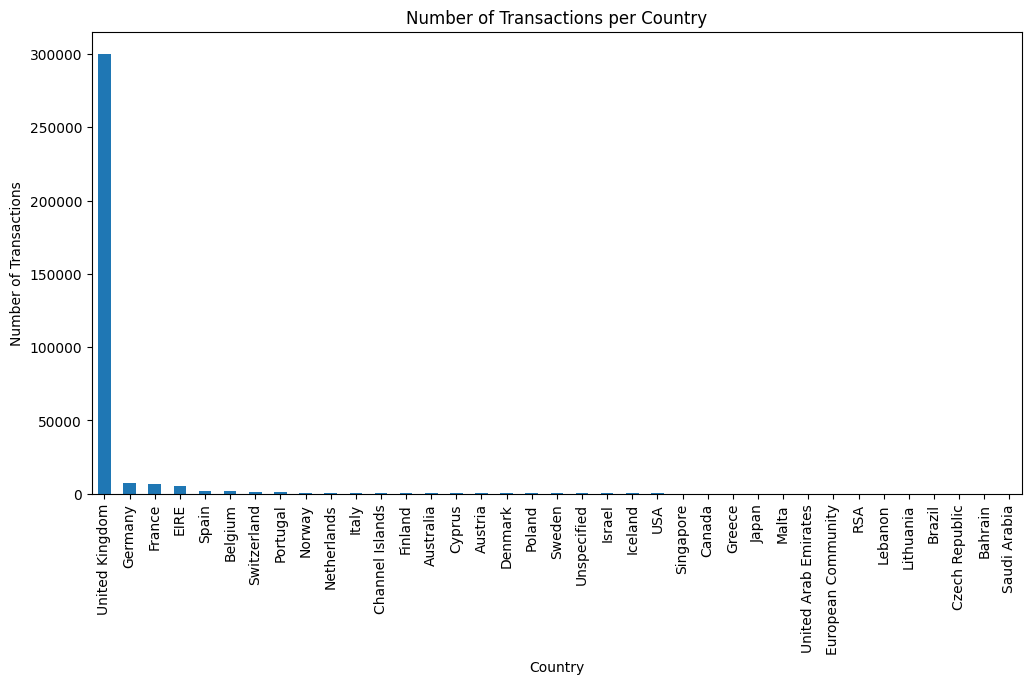

Repeat Purchasers         2703
Single-time Purchasers    1488
dtype: int64


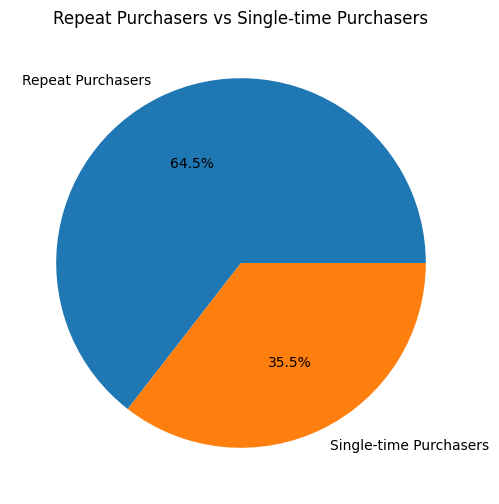

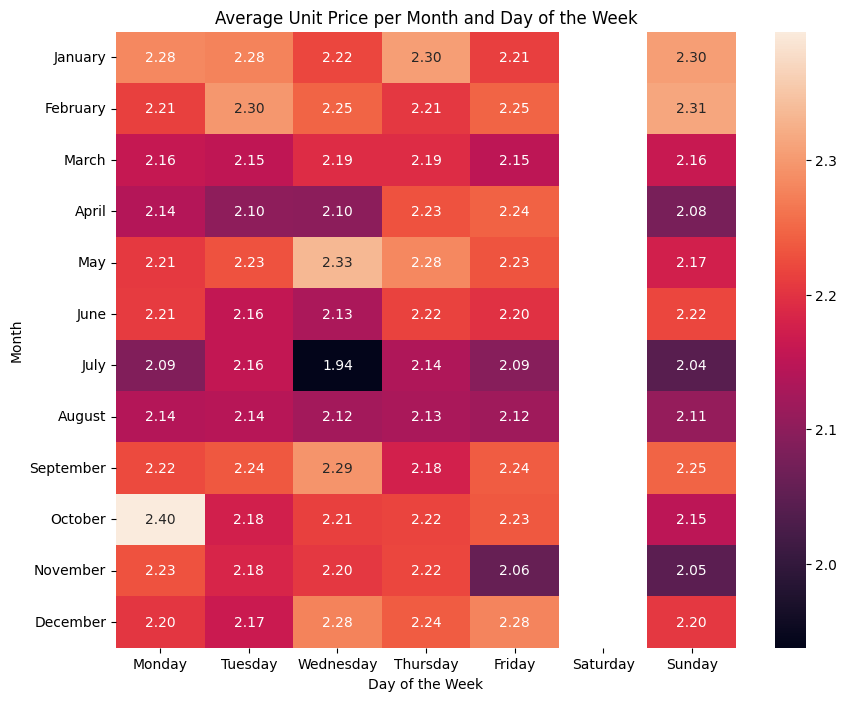

Top 10 Customers:
CustomerID
14911.0    49396
13089.0    20288
17841.0    19501
14298.0    17483
12748.0    14994
14096.0    13509
13081.0    12045
15159.0     8206
15311.0     8058
14156.0     7871
Name: Quantity, dtype: int64

Top 10 Items bought by most customers:
StockCode
85123A    771
47566     672
22720     635
84879     627
21212     597
85099B    580
22457     576
22138     575
23298     565
22960     563
Name: CustomerID, dtype: int64


In [9]:
# 1. Find free items
free_items = df[df["UnitPrice"] == 0]

print("Number of free items:", len(free_items))


# 2. Number of transactions per country
transactions_per_country = df["Country"].value_counts()

print(transactions_per_country)

plt.figure(figsize=(12, 6))
transactions_per_country.plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.title("Number of Transactions per Country")
plt.xticks(rotation=90)
plt.show()


# 3. Repeat purchasers vs single-time purchasers
customer_transactions = df.groupby("CustomerID")["InvoiceNo"].nunique()

repeat_customers = (customer_transactions > 1).sum()
single_time_customers = (customer_transactions == 1).sum()

customer_type = pd.Series(
    [repeat_customers, single_time_customers],
    index=["Repeat Purchasers", "Single-time Purchasers"]
)

print(customer_type)

plt.figure(figsize=(6, 6))
customer_type.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Repeat Purchasers vs Single-time Purchasers")
plt.show()


# 4. Heatmap of average UnitPrice by Month and DayOfWeek
df["Month"] = df["InvoiceDate"].dt.month_name()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

heatmap_data = df.pivot_table(
    values="UnitPrice",
    index="Month",
    columns="DayOfWeek",
    aggfunc="mean"
)

heatmap_data = heatmap_data.reindex(
    index=month_order,
    columns=day_order
)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f")
plt.xlabel("Day of the Week")
plt.ylabel("Month")
plt.title("Average Unit Price per Month and Day of the Week")
plt.show()


# 5. Top 10 customers by number of items purchased
top_customers = (
    df.groupby("CustomerID")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("Top 10 Customers:")
print(top_customers)


# Top 10 items bought by the most number of customers
top_items = (
    df.groupby("StockCode")["CustomerID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

print("\nTop 10 Items bought by most customers:")
print(top_items)

## Feature Engineering and Transformation

### Create new features to uncover better insights and drop the unwanted columns

* Create a new column which represents Total amount spent by each customer

    **Hint:** Quantity * UnitPrice

* Customer IDs are seen to be repeated. Maintain unique customer IDs by grouping and summing up all possible observations per customer.

    **Hint:** [pandas.groupby.agg](https://pandas.pydata.org/pandas-docs/version/0.22/generated/pandas.core.groupby.DataFrameGroupBy.agg.html)

**Note:** Perform the above operations in function, to reuse and apply the same for test data

In [10]:
def feature_engineering(df):
    # Calculate total amount spent
    df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

    # Group data by CustomerID
    customer_df = df.groupby("CustomerID").agg({
        "Quantity": "sum",
        "UnitPrice": "sum",
        "TotalAmount": "sum"
    }).reset_index()

    return customer_df


customer_df = feature_engineering(df)

customer_df.head()

,CustomerID,Quantity,UnitPrice,TotalAmount
0,12347.0,1893,389.93,3314.73
1,12348.0,140,3.90,90.20
2,12349.0,523,151.25,999.15
3,12350.0,196,25.30,294.40
4,12352.0,500,206.26,1130.94


### Scale the data

Apply `StandardScaler` on the features.

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    customer_df[["Quantity", "UnitPrice", "TotalAmount"]]
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=["Quantity", "UnitPrice", "TotalAmount"],
    index=customer_df.index
)

X_scaled.head()

,Quantity,UnitPrice,TotalAmount
0,1.029652,0.481805,1.040637
1,-0.366560,-0.381142,-0.425313
2,-0.061512,-0.051749,-0.012082
3,-0.321957,-0.333303,-0.332479
4,-0.079831,0.071222,0.047833


## Clustering

### Apply k-means algorithm to identify a specific number of clusters


* Fit the k-means model

* Extract and store the cluster centroids

Below are the parameters for k-means, which are helpful

**n_clusters** is no. of clusters specified

**k-means++** is a random initialization method for centroids to avoid random initialisation trap

**max_iter** is max no of iterations defined when k-means is running

**n_init** is no. of times k-means will run with different initial centroids

[why-is-k-means-slower-than-random-initialization-k-means](https://stats.stackexchange.com/questions/185396/why-is-k-means-slower-than-random-initialization-k-means/185422)

In [12]:
kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    max_iter=300,
    n_init=10,
    random_state=42
)

kmeans.fit(X_scaled)

# Store cluster labels
customer_df["Cluster"] = kmeans.labels_

# Store cluster centroids
centroids = kmeans.cluster_centers_

print("Cluster Centroids:")
print(centroids)

Cluster Centroids:
[[-0.18008514 -0.14569641 -0.17970659]
 [13.12006236 21.46533316 13.74177338]
 [ 1.6500027   1.23712232  1.64105757]
 [38.86435358 23.44344661 38.1680506 ]]


#### Find the optimal number of clusters (K) by using the [Elbow method](https://pythonprogramminglanguage.com/kmeans-elbow-method/).

Use the optimal no. of clusters and store the cluster centroids

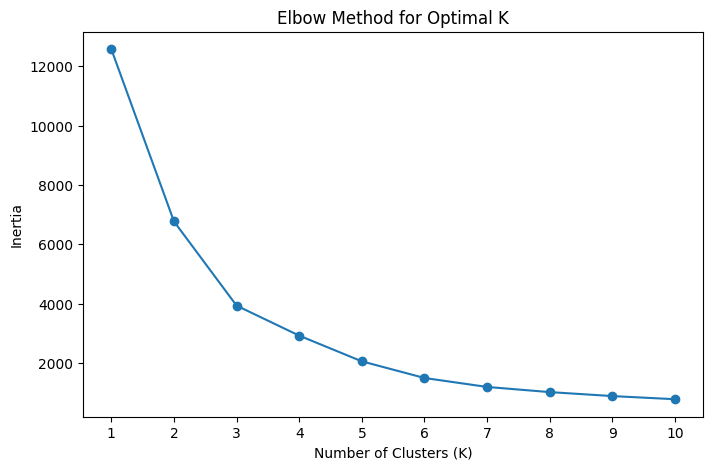

In [13]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        max_iter=300,
        n_init=10,
        random_state=42
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(K)
plt.show()

### Report Analysis

- Discuss the pros and cons of removing the missing values vs replacing with the mean values
- Based on the visualization of clusters, comment on the difference in buying patterns of each cluster
- What other methods could be used to determine the optimal no. of clusters?

# Type your answers here

**1. Discuss the pros and cons of removing the missing values vs replacing with the mean values**

**Removing missing values:**

**Pros:**  
Simple and easy to implement.  
Removes incomplete records that may not be useful for analysis.  

**Cons:**  
Reduces the size of the dataset.  
May introduce bias if the missing values are not randomly distributed.

**Replacing with mean values:**

**Pros:**  
Preserves the number of records.  
Useful when only a small number of values are missing.  

**Cons:**  
Can distort the original distribution of the data.  
May reduce the natural variation in the dataset.  


For this dataset, dropping rows with missing CustomerID is reasonable because customer-level clustering requires a valid customer identifier.


**2. Based on the visualization of clusters, comment on the difference in buying patterns of each cluster**

The customers are divided into different clusters based on their overall purchasing behaviour, including Quantity, UnitPrice, and TotalAmount.

**Cluster 1:** Represents customers with relatively lower purchasing activity and spending.  
**Cluster 2:** Represents customers with moderate purchasing activity and spending.  
**Cluster 3:** Represents customers with higher purchasing activity and spending compared with the previous clusters.  
**Cluster 4:** Represents customers with the highest purchasing activity and/or spending and can be considered the most valuable customer segment.  

Therefore, the clusters show that customers have different buying patterns.  
Some customers purchase fewer items and spend less, while others purchase frequently or spend significantly more.  
These segments can help the business target customers with different marketing strategies.


**3. What other methods could be used to determine the optimal number of clusters?**

Apart from the Elbow Method, the following methods can be used:

**Silhouette Analysis:** Measures how similar each data point is to its own cluster compared with other clusters.  
A higher silhouette score indicates better-defined clusters.

**Calinski-Harabasz Index:** Evaluates the separation and compactness of clusters.  
A higher score generally indicates better clustering.

Davies-Bouldin Index: Measures the average similarity between each cluster and its most similar cluster.  
A lower score indicates better-separated clusters.

These methods can be used along with the Elbow Method to select a suitable number of clusters.